In [1]:
import pandas as pd
import numpy as np

In [2]:
customer=pd.read_csv('/content/Test.csv')
customer.head(20)

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,458989,Female,Yes,36,Yes,Engineer,0.0,Low,1.0,Cat_6
1,458994,Male,Yes,37,Yes,Healthcare,8.0,Average,4.0,Cat_6
2,458996,Female,Yes,69,No,NaN,0.0,Low,1.0,Cat_6
3,459000,Male,Yes,59,No,Executive,11.0,High,2.0,Cat_6
4,459001,Female,No,19,No,Marketing,NaN,Low,4.0,Cat_6
5,459003,Male,Yes,47,Yes,Doctor,0.0,High,5.0,Cat_4
6,459005,Male,Yes,61,Yes,Doctor,5.0,Low,3.0,Cat_6
7,459008,Female,Yes,47,Yes,Artist,1.0,Average,3.0,Cat_6
8,459013,Male,Yes,50,Yes,Artist,2.0,Average,4.0,Cat_6
9,459014,Male,No,19,No,Healthcare,0.0,Low,4.0,Cat_6


In [4]:
customer.drop(columns=['Family_Size','Var_1'],inplace=True)
customer.head(20)

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score
0,458989,Female,Yes,36,Yes,Engineer,0.0,Low
1,458994,Male,Yes,37,Yes,Healthcare,8.0,Average
2,458996,Female,Yes,69,No,NaN,0.0,Low
3,459000,Male,Yes,59,No,Executive,11.0,High
4,459001,Female,No,19,No,Marketing,NaN,Low
5,459003,Male,Yes,47,Yes,Doctor,0.0,High
6,459005,Male,Yes,61,Yes,Doctor,5.0,Low
7,459008,Female,Yes,47,Yes,Artist,1.0,Average
8,459013,Male,Yes,50,Yes,Artist,2.0,Average
9,459014,Male,No,19,No,Healthcare,0.0,Low


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [13]:
X=customer[['ID','Work_Experience']]
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [15]:
# Re-extract the relevant columns from 'customer' to ensure a fresh, mutable copy
X_for_kmeans = customer[['ID', 'Work_Experience']].copy()

# Fill NaN values in 'Work_Experience' with its median before scaling
X_for_kmeans['Work_Experience'] = X_for_kmeans['Work_Experience'].fillna(X_for_kmeans['Work_Experience'].median())

# Re-initialize and apply StandardScaler to the cleaned data
scaler_cleaned = StandardScaler()
X_scaled_cleaned = scaler_cleaned.fit_transform(X_for_kmeans)

# Initialize KMeans, adding n_init='auto' to avoid future warnings
kmeans = KMeans(n_clusters=5, random_state=42, n_init='auto')

# Fit KMeans and get cluster labels directly using fit_predict
clusters = kmeans.fit_predict(X_scaled_cleaned)

# Assign the cluster labels to a new 'Cluster' column in the customer DataFrame
customer['Cluster'] = clusters

In [16]:
KMeans(n_clusters=5, random_state=42, n_init='auto')


KMeans(n_clusters=5, random_state=42)

In [17]:
centroids=kmeans.cluster_centers_

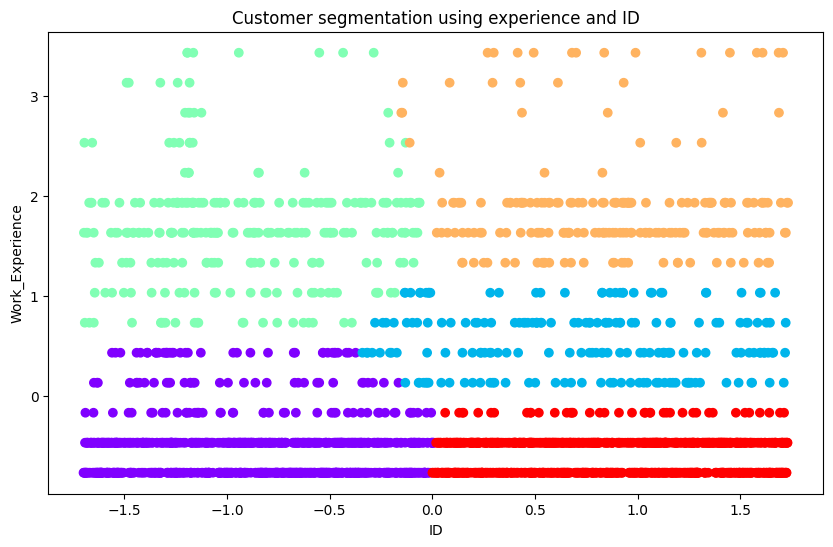

In [18]:
plt.figure(figsize=(10,6))
plt.scatter(X_scaled[:,0],X_scaled[:,1],c=clusters,cmap='rainbow')
plt.xlabel('ID')
plt.ylabel('Work_Experience')
plt.title('Customer segmentation using experience and ID')
plt.show()